<font color="black"><font size="7"><br>
     Projet 5 - Marketing Segmentation - EDA 
</font>
    

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Importing data

## Customers dataset

In [2]:
df_customers = pd.read_csv('data/olist_customers_dataset.csv')

In [3]:
df_customers.shape

(99441, 5)

In [4]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Missing values

In [5]:
df_customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

### EDA

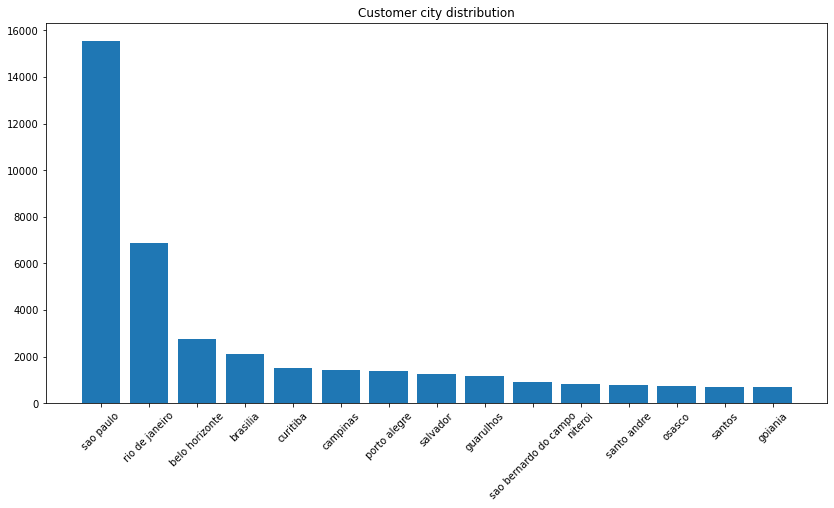

In [6]:
plt.figure(figsize=(14,7))
plt.bar(df_customers['customer_city'].value_counts().head(15).index,
        height= df_customers['customer_city'].value_counts().head(15).values)
plt.xticks(rotation=45)
plt.title('Customer city distribution')
plt.show()

## Orders dataset

In [7]:
df_orders = pd.read_csv('data/olist_orders_dataset.csv',
                        parse_dates=[3, 4, 5, 6, 7])

In [8]:
df_orders.shape

(99441, 8)

In [9]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [10]:
df_orders['order_id'].unique().shape

(99441,)

In [11]:
df_orders['customer_id'].unique().shape

(99441,)

### Missing values

In [12]:
df_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### Feature engineering

Get weekdays of purchase

In [13]:
df_orders["purchase_weekday"] = df_orders["order_purchase_timestamp"].dt.day_name()

Get period of the day of purchase

In [14]:
df_orders['purchase_period']=df_orders['order_purchase_timestamp'].dt.hour//6

Difference between etimated delivery and actual delivery

In [15]:
df_orders['delivery_difference_time']=df_orders['order_delivered_customer_date']-df_orders['order_estimated_delivery_date']

In [16]:
last_order = df_orders['order_purchase_timestamp'].max()

In [17]:
df_orders['recency']=last_order - df_orders['order_purchase_timestamp']

In [18]:
df_orders['recency']=df_orders['recency'].dt.total_seconds()//86400

In [19]:
df_orders['recency']

0        380.0
1         84.0
2         70.0
3        332.0
4        245.0
         ...  
99436    587.0
99437    253.0
99438    416.0
99439    281.0
99440    222.0
Name: recency, Length: 99441, dtype: float64

### EDA

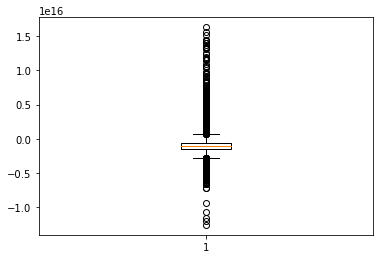

In [20]:
plt.boxplot(df_orders['delivery_difference_time'])
plt.show()

In [21]:
A=pd.Timedelta(15,unit='D')

In [22]:
df_orders['delivery_difference_time'].max()

Timedelta('188 days 23:24:07')

In [23]:
df_orders[df_orders['delivery_difference_time']>A].shape

(1384, 12)

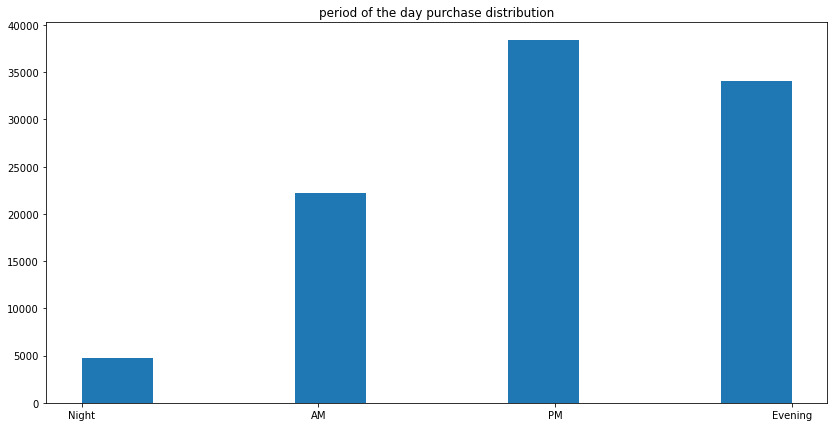

In [24]:
plt.figure(figsize=(14,7))
plt.hist(df_orders['purchase_period'])
plt.title('period of the day purchase distribution')
plt.xticks(ticks=[0,1,2,3],labels=['Night','AM','PM','Evening'])
plt.show()

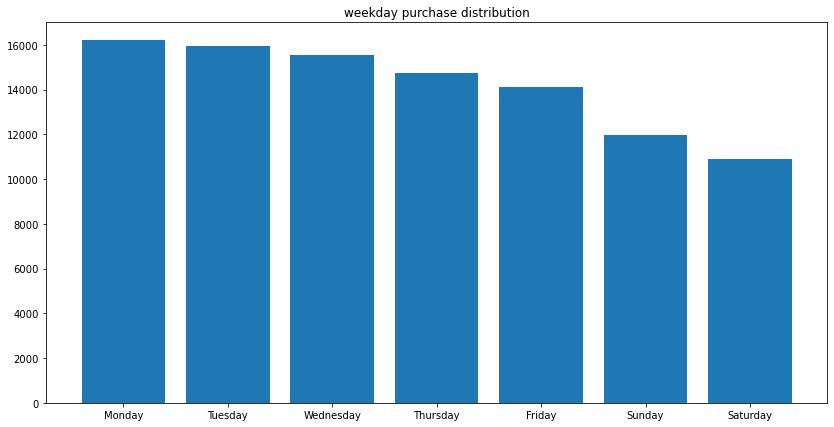

In [25]:
plt.figure(figsize=(14,7))
plt.bar(df_orders.groupby(['purchase_weekday']).count()['order_id'].sort_values(ascending=False).index,
       height=df_orders.groupby(['purchase_weekday']).count()['order_id'].sort_values(ascending=False).values)
plt.title('weekday purchase distribution')
plt.show()

In [26]:
A = df_orders.groupby(['purchase_weekday','purchase_period']).count()['order_id']

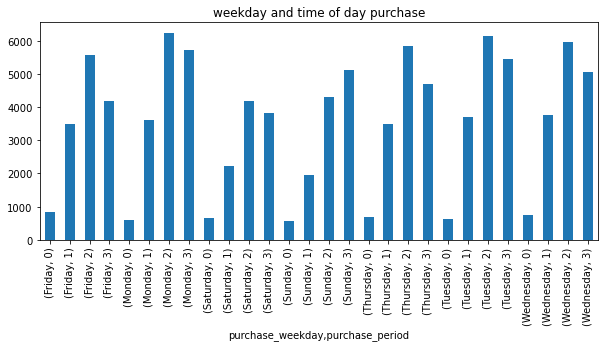

In [27]:
A.plot.bar(x='count',figsize=(10,4))
plt.title('weekday and time of day purchase')
plt.show()

In [28]:
df_orders.describe()

,purchase_period,delivery_difference_time,recency
count,99441.000000,96476,99441.000000
mean,2.023934,-12 days +19:42:04.042383575,289.900192
std,0.869866,10 days 04:28:00.181984555,153.667316
min,0.000000,-147 days +23:36:47,0.000000
25%,1.000000,-17 days +18:08:05.250000,166.000000
50%,2.000000,-12 days +01:13:31.500000,271.000000
75%,3.000000,-7 days +14:38:24,400.000000
max,3.000000,188 days 23:24:07,772.000000


### Joining datasets

In [29]:
master = df_customers.join(df_orders.set_index('customer_id'),on='customer_id')

In [30]:
master.shape

(99441, 16)

In [31]:
master

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_weekday,purchase_period,delivery_difference_time,recency
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,Tuesday,2,-11 days +10:35:35,519.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,Friday,3,-8 days +12:41:19,277.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,Saturday,2,1 days 17:58:51,151.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,Tuesday,2,-13 days +16:04:25,218.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,Sunday,1,-6 days +20:55:48,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,Saturday,2,-12 days +20:06:37,193.0
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,Wednesday,1,-9 days +18:54:45,196.0
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,Sunday,3,7 days 19:03:15,191.0
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,Friday,3,-19 days +19:58:39,347.0


## Payments dataset

In [32]:
df_payments = pd.read_csv('data/olist_order_payments_dataset.csv')

In [33]:
df_payments.shape

(103886, 5)

In [34]:
df_payments['order_id'].unique().shape

(99440,)

In [35]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [36]:
df_payments.dtypes

order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

### Missing values

In [37]:
df_payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

### EDA

In [38]:
df_payments['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

In [39]:
df_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [40]:
df_payments.groupby(['order_id']).sum()['payment_value'].describe()

count    99440.000000
mean       160.990267
std        221.951257
min          0.000000
25%         62.010000
50%        105.290000
75%        176.970000
max      13664.080000
Name: payment_value, dtype: float64

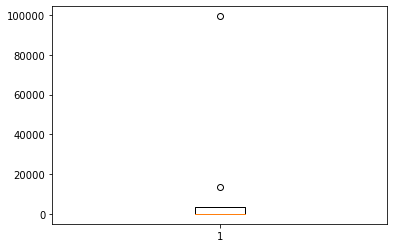

In [41]:
plt.boxplot(df_payments.groupby(['order_id']).sum()['payment_value'].describe())
plt.show()

### Feature engineering

Total payment amount

In [42]:
A=pd.DataFrame(df_payments.groupby(['order_id']).sum())

In [43]:
A['total_order_payment_amount']=A['payment_value']

In [44]:
A.drop(columns=['payment_sequential','payment_installments','payment_value'],inplace=True)

In [45]:
df_payments=df_payments.join(A,on='order_id')

### Joining dataset

In [46]:
df_payments.shape

(103886, 6)

In [47]:
master = df_payments.join(master.set_index('order_id'),on='order_id',how='outer')

In [48]:
master.shape

(103887, 21)

In [49]:
master.index = pd.RangeIndex(start=0, stop=master.shape[0], step=1)

In [275]:
master

,order_id,payment_sequential,payment_type,payment_installments,payment_value,total_order_payment_amount,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,...,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_weekday,purchase_period,delivery_difference_time,recency,review_score
0,b81ef226f3fe1789b1e8b2acac839d17,1.0,credit_card,8.0,99.33,99.33,0a8556ac6be836b46b3e89920d59291c,708ab75d2a007f0564aedd11139c7708,39801,teofilo otoni,...,2018-04-25 22:01:49,2018-04-25 22:15:09,2018-05-02 15:20:00,2018-05-09 17:36:51,2018-05-22,Wednesday,3,-13 days +17:36:51,174.0,1.0
1,a9810da82917af2d9aefd1278f1dcfa0,1.0,credit_card,1.0,24.39,24.39,f2c7fc58a9de810828715166c672f10a,a8b9d3a27068454b1c98cc67d4e31e6f,2422,sao paulo,...,2018-06-26 11:01:38,2018-06-26 11:18:58,2018-06-28 14:18:00,2018-06-29 20:32:09,2018-07-16,Tuesday,1,-17 days +20:32:09,113.0,5.0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1.0,credit_card,1.0,65.71,65.71,25b14b69de0b6e184ae6fe2755e478f9,6f70c0b2f7552832ba46eb57b1c5651e,2652,sao paulo,...,2017-12-12 11:19:55,2017-12-14 09:52:34,2017-12-15 20:13:22,2017-12-18 17:24:41,2018-01-04,Tuesday,1,-17 days +17:24:41,309.0,5.0
3,ba78997921bbcdc1373bb41e913ab953,1.0,credit_card,8.0,107.78,107.78,7a5d8efaaa1081f800628c30d2b0728f,87695ed086ebd36f20404c82d20fca87,36060,juiz de fora,...,2017-12-06 12:04:06,2017-12-06 12:13:20,2017-12-07 20:28:28,2017-12-21 01:35:51,2018-01-04,Wednesday,2,-14 days +01:35:51,315.0,5.0
4,42fdf880ba16b47b59251dd489d4441a,1.0,credit_card,2.0,128.45,128.45,15fd6fb8f8312dbb4674e4518d6fa3b3,4291db0da71914754618cd789aebcd56,18570,conchas,...,2018-05-21 13:59:17,2018-05-21 16:14:41,2018-05-22 11:46:00,2018-06-01 21:44:53,2018-06-13,Monday,2,-12 days +21:44:53,149.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103882,7b905861d7c825891d6347454ea7863f,1.0,credit_card,2.0,96.80,96.80,2079230c765a88530822a34a4cec2aa0,53b30ca78efb2b7efcd3f9e461587eb2,30210,belo horizonte,...,2017-08-18 09:45:35,2017-08-18 10:04:56,2017-08-18 18:04:24,2017-08-23 22:25:56,2017-09-12,Friday,1,-20 days +22:25:56,425.0,5.0
103883,32609bbb3dd69b3c066a6860554a77bf,1.0,credit_card,1.0,47.77,47.77,e4abb5057ec8cfda9759c0dc415a8188,d3c7da954a324253814096bcaf240e4e,1519,sao paulo,...,2017-11-18 17:27:14,2017-11-18 17:46:05,NaT,NaT,2017-12-05,Saturday,2,NaT,333.0,1.0
103884,b8b61059626efa996a60be9bb9320e10,1.0,credit_card,5.0,369.54,369.54,5d719b0d300663188169c6560e243f27,b84dc68f02f122a88d7e7bbd37b06204,22733,rio de janeiro,...,2018-08-07 23:26:13,2018-08-07 23:45:00,2018-08-09 11:46:00,2018-08-21 22:41:46,2018-08-24,Tuesday,3,-3 days +22:41:46,70.0,5.0
103885,28bbae6599b09d39ca406b747b6632b1,1.0,boleto,1.0,191.58,191.58,4c7f868f43b5cff577b0becb8c8b7860,b1f51a4e19da3338e51fbcfabefad1bf,23059,rio de janeiro,...,2017-12-05 08:18:35,2017-12-06 02:50:09,2017-12-08 00:51:47,2018-02-05 14:59:09,2017-12-29,Tuesday,1,38 days 14:59:09,316.0,1.0


## Reviews dataset

In [247]:
df_reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

{'whiskers': [<matplotlib.lines.Line2D at 0x1d2b7c90790>,
 'caps': [<matplotlib.lines.Line2D at 0x1d2b7c92040>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d2b7c90340>],
 'medians': [<matplotlib.lines.Line2D at 0x1d2b7c928b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d2b7c92cd0>],
 'means': []}

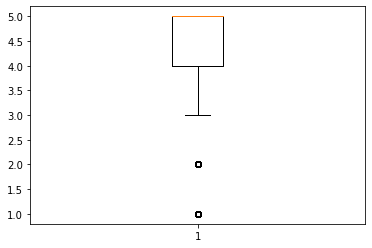

In [279]:
plt.boxplot(df_reviews['review_score'])

<AxesSubplot:xlabel='review_score', ylabel='Count'>

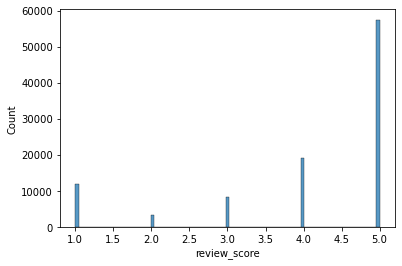

In [282]:
sns.histplot(df_reviews['review_score'])

<AxesSubplot:xlabel='review_score', ylabel='Count'>

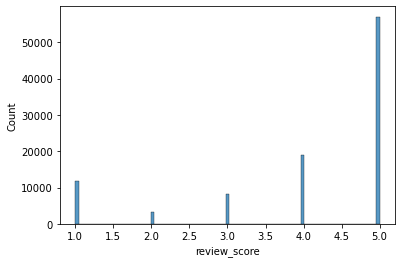

In [283]:
sns.histplot(df_reviews.groupby('order_id').mean()['review_score'])

In [281]:
df_reviews['review_score'].describe()

count    100000.000000
mean          4.070890
std           1.359663
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

### Joining dataset

In [266]:
master = master.join(df_reviews.groupby('order_id').mean(),on='order_id')

In [272]:
master['review_score'].mean()

4.0690477794783435

## Building final dataset

In [51]:
df_final = pd.DataFrame(df_customers['customer_unique_id'].unique(),columns=['customer_unique_id'])

### Frequency

In [52]:
master.groupby('customer_unique_id').count()['order_id']

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
                                   ..
fffcf5a5ff07b0908bd4e2dbc735a684    1
fffea47cd6d3cc0a88bd621562a9d061    1
ffff371b4d645b6ecea244b27531430a    1
ffff5962728ec6157033ef9805bacc48    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: order_id, Length: 96096, dtype: int64

In [53]:
df_final=df_final.join(master.groupby('customer_unique_id').count()['order_id'],on='customer_unique_id')

In [54]:
df_final.rename(columns={'order_id':'frequency'},inplace=True)

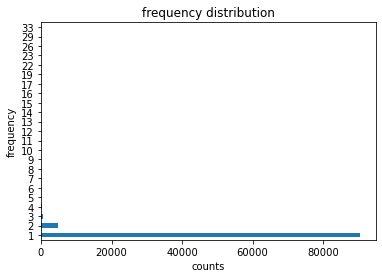

In [55]:
df_final.groupby('frequency')['customer_unique_id'].count().plot(kind='barh')
plt.title('frequency distribution')
plt.xlabel('counts')
plt.show()

### Recency

In [56]:
df_final=df_final.join(master[['recency','customer_unique_id']].groupby('customer_unique_id').min(),
                       on='customer_unique_id')

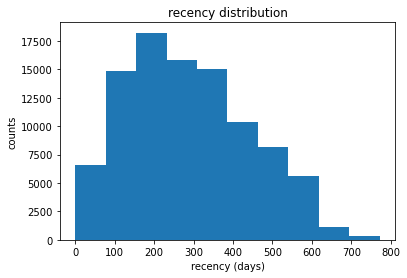

In [57]:
plt.hist(df_final['recency'])
plt.title('recency distribution')
plt.xlabel('recency (days)')
plt.ylabel('counts')
plt.show()

### Monetary

In [58]:
df_final=df_final.join(master[['customer_unique_id','payment_value']].groupby('customer_unique_id').sum(),
                       on='customer_unique_id')

In [59]:
df_final.rename(columns={'payment_value':'monetary'},inplace=True)

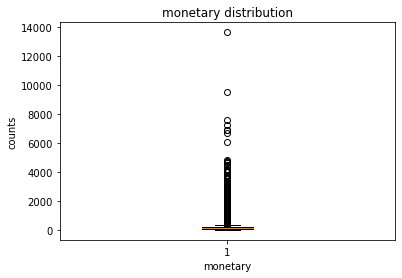

In [60]:
plt.boxplot(df_final['monetary'])
plt.title('monetary distribution')
plt.xlabel('monetary')
plt.ylabel('counts')
plt.show()

In [61]:
df_final['monetary_log']=np.log(df_final['monetary'])

C:\Users\Soyann\Code\Install\anaconda3\lib\site-packages\pandas\core\series.py:726: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


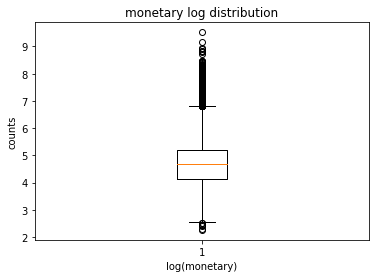

In [62]:
plt.boxplot(df_final['monetary_log'])
plt.title('monetary log distribution')
plt.xlabel('log(monetary)')
plt.ylabel('counts')
plt.show()

### Reviews

In [276]:
df_final=df_final.join(master[['customer_unique_id','review_score']].groupby('customer_unique_id').mean(),
                       on='customer_unique_id')

In [277]:
df_final.describe()

,frequency,recency,monetary,monetary_log,frequency_score,recency_score,monetary_score,RFM_score,RFM_manual_cluster,review_score
count,96096.000000,96096.000000,96096.000000,9.609600e+04,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000
mean,1.081075,287.735691,166.592492,-inf,4.761530,2.996056,2.999990,10.757576,1.958396,4.069514
std,0.462545,153.414676,231.428332,NaN,0.947112,1.415036,1.414239,2.295090,0.714967,1.353568
min,1.000000,0.000000,0.000000,-inf,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000
25%,1.000000,163.000000,63.120000,4.145038e+00,5.000000,2.000000,2.000000,9.000000,1.000000,4.000000
50%,1.000000,268.000000,108.000000,4.682131e+00,5.000000,3.000000,3.000000,11.000000,2.000000,5.000000
75%,1.000000,397.000000,183.530000,5.212378e+00,5.000000,4.000000,4.000000,12.000000,2.000000,5.000000
max,33.000000,772.000000,13664.080000,9.522526e+00,5.000000,5.000000,5.000000,15.000000,3.000000,5.000000


## Manual RFM clustering

### Quantile calculation

In [63]:
quantile = df_final.quantile(q=np.arange(0.2,1,0.2))

In [64]:
quantile

,frequency,recency,monetary,monetary_log
0.2,1.0,142.0,55.37,4.014038
0.4,1.0,227.0,87.56,4.472324
0.6,1.0,317.0,133.21,4.891927
0.8,1.0,433.0,209.60,5.345201


### RFM scores

In [65]:
df_final['frequency_score'] = [5 if 0 < f <= quantile.iloc[0]['frequency']
                             else 4 if quantile.iloc[0]['frequency'] < f <= quantile.iloc[1]['frequency']
                             else 3 if quantile.iloc[1]['frequency'] < f <= quantile.iloc[2]['frequency']
                             else 2 if quantile.iloc[2]['frequency'] < f <= quantile.iloc[3]['frequency']
                             else 1 for f in df_final['frequency']]

In [66]:
df_final['recency_score'] = [1 if 0 < f <= quantile.iloc[0]['recency']
                             else 2 if quantile.iloc[0]['recency'] < f <= quantile.iloc[1]['recency']
                             else 3 if quantile.iloc[1]['recency'] < f <= quantile.iloc[2]['recency']
                             else 4 if quantile.iloc[2]['recency'] < f <= quantile.iloc[3]['recency']
                             else 5 for f in df_final['recency']]

In [67]:
df_final['monetary_score'] = [5 if 0 < f <= quantile.iloc[0]['monetary_log']
                             else 4 if quantile.iloc[0]['monetary_log'] < f <= quantile.iloc[1]['monetary_log']
                             else 3 if quantile.iloc[1]['monetary_log'] < f <= quantile.iloc[2]['monetary_log']
                             else 2 if quantile.iloc[2]['monetary_log'] < f <= quantile.iloc[3]['monetary_log']
                             else 1 for f in df_final['monetary_log']]

In [68]:
df_final['RFM_score'] = df_final['frequency_score'] + \
    df_final['recency_score'] + df_final['monetary_score']

In [69]:
df_final

,customer_unique_id,frequency,recency,monetary,monetary_log,frequency_score,recency_score,monetary_score,RFM_score
0,861eff4711a542e4b93843c6dd7febb0,1,519.0,146.87,4.989548,5,5,2,12
1,290c77bc529b7ac935b93aa66c333dc3,1,277.0,335.48,5.815562,5,3,1,9
2,060e732b5b29e8181a18229c7b0b2b5e,1,151.0,157.73,5.060885,5,2,2,9
3,259dac757896d24d7702b9acbbff3f3c,1,218.0,173.30,5.155024,5,2,2,9
4,345ecd01c38d18a9036ed96c73b8d066,1,80.0,252.25,5.530421,5,1,1,7
...,...,...,...,...,...,...,...,...,...
96091,1a29b476fee25c95fbafc67c5ac95cf8,1,193.0,88.78,4.486161,5,2,3,10
96092,d52a67c98be1cf6a5c84435bd38d095d,1,196.0,129.06,4.860277,5,2,3,10
96093,e9f50caf99f032f0bf3c55141f019d99,1,191.0,56.04,4.026066,5,2,4,11
96094,73c2643a0a458b49f58cea58833b192e,1,347.0,711.07,6.566771,5,4,1,10


### EDA

In [176]:
df_final.isna().sum()

customer_unique_id    0
frequency             0
recency               0
monetary              0
monetary_log          0
frequency_score       0
recency_score         0
monetary_score        0
RFM_score             0
RFM_manual_cluster    0
dtype: int64

In [186]:
df_final

,customer_unique_id,frequency,recency,monetary,monetary_log,frequency_score,recency_score,monetary_score,RFM_score,RFM_manual_cluster
0,861eff4711a542e4b93843c6dd7febb0,1,519.0,146.87,4.989548,5,5,2,12,2
1,290c77bc529b7ac935b93aa66c333dc3,1,277.0,335.48,5.815562,5,3,1,9,1
2,060e732b5b29e8181a18229c7b0b2b5e,1,151.0,157.73,5.060885,5,2,2,9,1
3,259dac757896d24d7702b9acbbff3f3c,1,218.0,173.30,5.155024,5,2,2,9,1
4,345ecd01c38d18a9036ed96c73b8d066,1,80.0,252.25,5.530421,5,1,1,7,1
...,...,...,...,...,...,...,...,...,...,...
96091,1a29b476fee25c95fbafc67c5ac95cf8,1,193.0,88.78,4.486161,5,2,3,10,2
96092,d52a67c98be1cf6a5c84435bd38d095d,1,196.0,129.06,4.860277,5,2,3,10,2
96093,e9f50caf99f032f0bf3c55141f019d99,1,191.0,56.04,4.026066,5,2,4,11,2
96094,73c2643a0a458b49f58cea58833b192e,1,347.0,711.07,6.566771,5,4,1,10,2


#### ANOVA

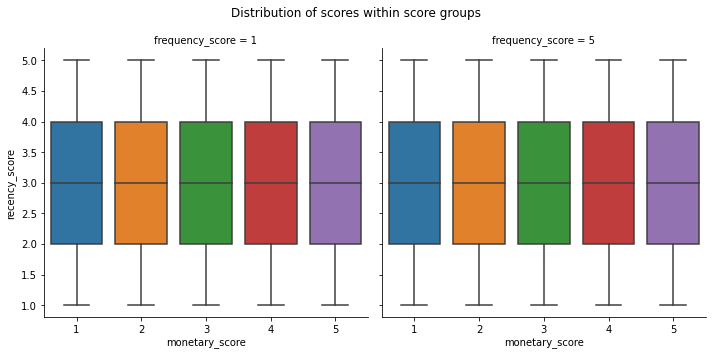

In [224]:

sns.catplot(x='monetary_score',
            y='recency_score',
            col='frequency_score',
            kind='box',
           data=df_final)
plt.suptitle('Distribution of scores within score groups')
plt.tight_layout()
plt.show()

### Manual Clustering

#### Number of clusters

In [203]:
k = 2

In [204]:
rfm_quantile = df_final['RFM_score'].quantile([1/3,2/3])

In [205]:
rfm_quantile.iloc[0]

10.0

In [206]:
df_final['RFM_manual_cluster'] = [ 1 if 0 < f < rfm_quantile.iloc[0]
                                 else 2 if rfm_quantile.iloc[0] <= f <= rfm_quantile.iloc[1]
                                 else 3 for f in df_final['RFM_score'] ]

In [207]:
df_final['RFM_manual_cluster'].unique()

array([2, 1, 3], dtype=int64)

#### Cluster analysis

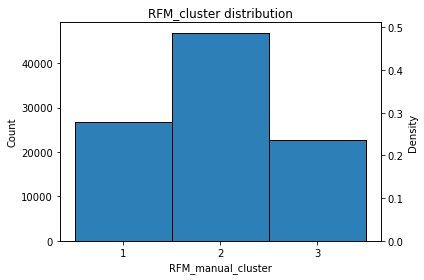

In [208]:
fig, ax = plt.subplots()

sns.histplot(df_final['RFM_manual_cluster'],discrete=True, ax=ax)

ax2 = ax.twinx()
sns.histplot(df_final['RFM_manual_cluster'],stat='density',discrete=True, ax=ax2)

plt.title('RFM_cluster distribution')
plt.xlabel('RFM_cluster')
plt.xticks([1,2,3],['1','2','3'])


plt.tight_layout()
plt.show()


In [209]:
df_final.groupby('RFM_manual_cluster').count()[['recency','monetary','frequency']]

,recency,monetary,frequency
RFM_manual_cluster,,,
1,26643,26643,26643
2,46808,46808,46808
3,22645,22645,22645


<AxesSubplot:xlabel='RFM_manual_cluster'>

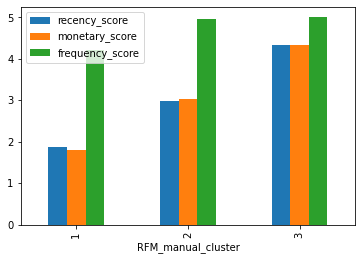

In [210]:
df_final.groupby('RFM_manual_cluster').mean()[['recency_score','monetary_score','frequency_score']].plot(kind='bar')

In [211]:
A = df_final.groupby('RFM_manual_cluster').mean()[['recency_score','monetary_score','frequency_score']]

In [212]:
A

,recency_score,monetary_score,frequency_score
RFM_manual_cluster,,,
1,1.880607,1.795969,4.208948
2,2.986028,3.038177,4.960690
3,4.329168,4.337646,5.000000


In [213]:
from math import pi


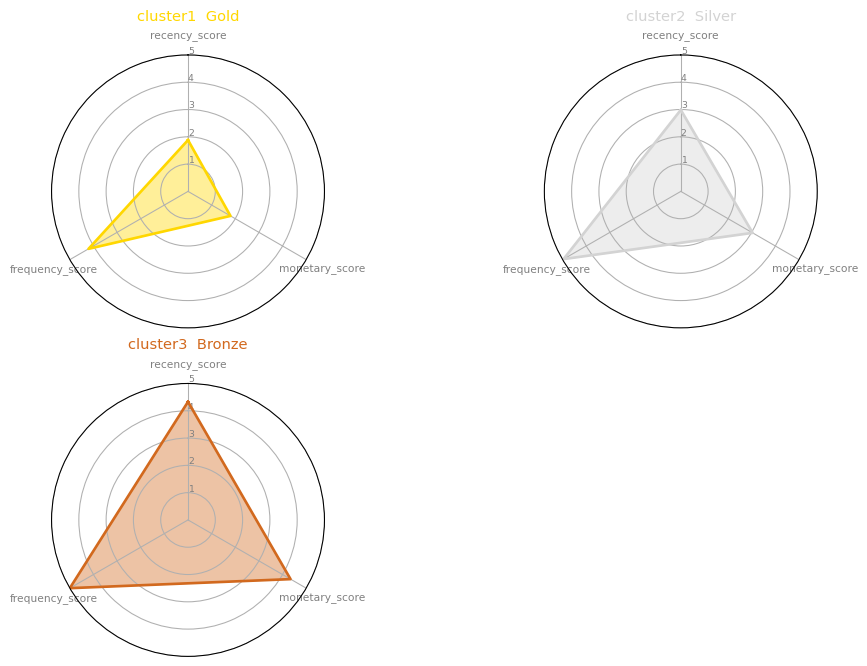

In [244]:

# ------- PART 1: Define a function that do a plot for one line of the dataset!
 
def make_spider( row, title, color):
 
    # number of variable
    categories=list(A)
    N = len(categories)
 
    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
 
    # Initialise the spider plot
    ax = plt.subplot(3,2,row, polar=True, )
 
    # If you want the first axis to be on top:
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
 
    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], categories, color='grey', size=8)
 
    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([1,2,3,4,5], ["1","2","3","4","5"], color="grey", size=7)
    plt.ylim(0,5)
 
    # Ind1
    values=A.loc[row].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)
 
    # Add a title
    plt.title(title, size=11, color=color, y=1.1)
    return None
 
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi=96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)
 
# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['gold','lightgrey','chocolate']
labels=['Gold','Silver','Bronze']

# Loop to plot
for row in range(0, len(A.index)):
    make_spider( row=row+1, title='cluster'+str(row+1)+'  '+ str(labels[row]), color=my_palette[row])

plt.tight_layout()

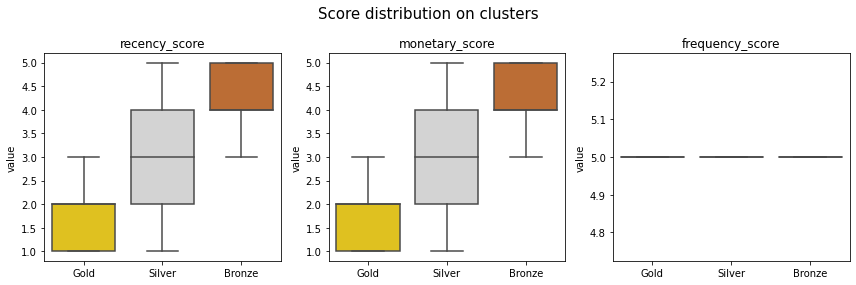

In [240]:
fig, axes = plt.subplots(1,3)
fig.set_size_inches(12, 4)
i=0
for col in df_final[['recency_score','monetary_score','frequency_score']].columns:
    ax=axes[i%3]
    sns.boxplot(x='RFM_manual_cluster',
               y=col,
               data=df_final,
               #palette='rainbow',
               palette=my_palette,
               showfliers=False,
               ax=ax
               )
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.set_xticklabels(['Gold','Silver','Bronze'])
    ax.set_ylabel('value')
    i+=1
fig.suptitle('Score distribution on clusters',fontsize=15)
plt.tight_layout()
plt.show()